<a href="https://colab.research.google.com/github/tonycuenca99-hue/ARQUIVOS-IA/blob/main/WEEKLY_REPORT_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
# CARREGAR OS DADOS
from google.colab import files
uploaded = files.upload()

Saving iiot_30min_norm.csv to iiot_30min_norm (2).csv


In [ ]:
 #CARREGAMENTO E PREPARAÇÃO DOS DADOS
df = pd.read_csv("iiot_30min_norm.csv")

In [ ]:
target_column = 'TIME'

X = df.drop(columns=["TIME"])
y = df["TIME"]

In [ ]:
# Divisão treino/teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
#Normalização das features

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
# 4. Treinamento dos modelos

models = {
    "Lasso Regression": Lasso(alpha=0.001, random_state=42, max_iter=10000),
    "Ridge Regression": Ridge(alpha=1.0, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "XGBoost": XGBRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        objective="reg:squarederror"
    ),
}

In [ ]:
# 5. Avaliação e comparação dos modelos
results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append([name, mse, mae, r2])

ValueError: could not convert string to float: '2020-07-14 02:30:00+00:00'

/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


<Figure size 2000x1000 with 0 Axes>

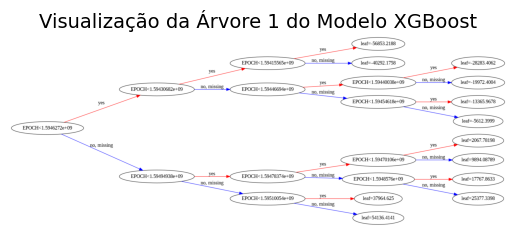

In [ ]:
#VISUALIZAÇÃO DE UMA ÁRVORE DO XGBOOST
plt.figure(figsize=(20, 10))
plot_tree(xgb, num_trees=0, rankdir='LR')  # Mostra a primeira árvore
plt.title("Visualização da Árvore 1 do Modelo XGBoost", fontsize=14)
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor, plot_tree
import matplotlib.pyplot as plt

In [ ]:
# CARREGAR OS DADOS
from google.colab import files
uploaded = files.upload()

Saving iiot_30min_norm.csv to iiot_30min_norm (1).csv


In [ ]:
df = pd.read_csv("iiot_30min_norm.csv")

In [ ]:
# Drop the 'TIME' column from X
X = df.drop('TIME', axis=1)
# Assign the 'EPOCH' column as the target variable y
y = df['EPOCH']

In [ ]:
# Divisão treino/teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 3. Normalização das features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# 4. Treinamento dos modelos
models = {
    "Lasso Regression": Lasso(alpha=0.001, random_state=42, max_iter=10000),
    "Ridge Regression": Ridge(alpha=1.0, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "XGBoost": XGBRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        objective="reg:squarederror"
    ),
}


In [ ]:
# 5. Avaliação e comparação dos modelos
results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append([name, mse, mae, r2])

In [ ]:
# 6. Criar tabela comparativa
results_df = pd.DataFrame(results, columns=["Modelo", "MSE", "MAE", "R²"])
print(results_df)

             Modelo           MSE          MAE        R²
0  Lasso Regression  1.612724e+04   100.607185  1.000000
1  Ridge Regression  1.158496e+06   854.922791  0.999992
2     Random Forest  4.878188e+06  1584.597222  0.999965
3           XGBoost  1.131611e+07  2501.333252  0.999918
